### **Router Workflow**

In [34]:
from pydantic import BaseModel, Field
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [35]:
class llm_op(BaseModel):
    platform: Literal['insta','linkedin', 'twitter'] = Field(description="Platform on which we want to post our content. Your content generation style should be according to these platforms.")
    topic: str = Field(description="Topic for which we are generating content")

class GraphState(TypedDict):
    user_input: str
    insta: str
    linkedin: str
    twitter: str


In [36]:

llm = ChatOpenAI(model='gpt-5-mini',temperature=0)
structured_llm = llm.with_structured_output(llm_op)


In [37]:
def router(state):
    structured_response = structured_llm.invoke(
        state['user_input']
    )
    platform = structured_response.platform
    topic = structured_response.topic

    state[platform] = platform
    state['user_input'] = topic

    return state


In [38]:
def insta(state):
    insta_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'you are a insta post generator'),
            ('user', '{topic}')
        ]
    )

    chain = insta_prompt | llm
    response = chain.invoke(
        {
            'topic': state['user_input']
        }
    ).content

    state['insta'] = response
    return state

In [39]:
def linkedin(state):
    linkedin_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'you are a linkedin post generator'),
            ('user', '{topic}')
        ]
    )

    chain = linkedin_prompt | llm
    response = chain.invoke(
        {
            'topic': state['user_input']
        }
    ).content

    state['linkedin'] = response
    return state

In [40]:
def twitter(state):
    twitter_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'you are a twitter post generator'),
            ('user', '{topic}')
        ]
    )

    chain = twitter_prompt | llm
    response = chain.invoke(
        {
            'topic': state['user_input']
        }
    ).content

    state['twitter'] = response
    return state

In [46]:
def route(state):
    if state.get('insta', ""):
        return 'insta'
    elif state.get('linkedin', ""):
        return 'linkedin'
    else:
        return 'twitter'

In [47]:
router_graph = StateGraph(GraphState)
router_graph.add_node('router', router)
router_graph.add_node('insta',insta)
router_graph.add_node('linkedin',linkedin)
router_graph.add_node('twitter',twitter)

router_graph.add_edge(START, 'router')
router_graph.add_conditional_edges('router', route, {'insta':'insta', 'linkedin':'linkedin', 'twitter':'twitter'})
router_graph.add_edge('insta',END)
router_graph.add_edge('linkedin',END)
router_graph.add_edge('twitter',END)


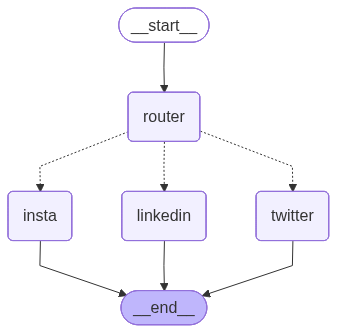

In [48]:
router_graph_compiled = router_graph.compile()
router_graph_compiled

In [49]:
router_graph_compiled.invoke(
    {
        'user_input':'Create content for an twitter post on AI please'
    }
)

{'user_input': 'AI: amplify creativity, solve real problems, but build with empathy. Learn, test, and use responsibly. The future we want is the one we design. #AI #ResponsibleAI 🤖',
 'twitter': "Here are several tweet variations you can use — different tones and lengths:\n\n- AI: amplify creativity, solve real problems, build with empathy. Learn, test, and use responsibly. The future we want is the one we design. #AI #ResponsibleAI 🤖\n\n- Design AI to amplify creativity and solve real problems — with empathy. Learn, test, and use responsibly. Our future is the one we build. #ResponsibleAI #AI 🤖\n\n- Want a better future? Build AI that amplifies creativity, solves real problems, and centers empathy. Learn, test, and use responsibly. We design tomorrow. #AI #ResponsibleAI\n\n- AI can amplify creativity and solve complex problems—if we build it with empathy, rigorous testing, and responsibility. The future is what we design. #ResponsibleAI #AI\n\n- Amplify creativity. Solve real problems